# 信頼バンドの根探索 (`find_confidence_band`)

等間隔グリッドの代わりに、ブラケット＋幾何二分法でバンドの上下端を直接探す例。
最も広い 2σ で外側をブラケットし、各レベル (1σ/90%/2σ) の端を入れ子で詰める。

- `num_pseudo_data`: ブラケット段階の擬似データ数（粗くてよい）
- `n_pseudo_edge`: 端の二分法で使う擬似データ数（cutoff のノイズを抑えるため大きめ）
- `seed`: 固定すると各点が再現可能になり、二分法のジッターが減る


Optimization Complete.
Minimum chi-squared: 8.406318406002375e-09
Plot saved as scenario_bkg_flat/flux_comparison_bkg_flat.pdf


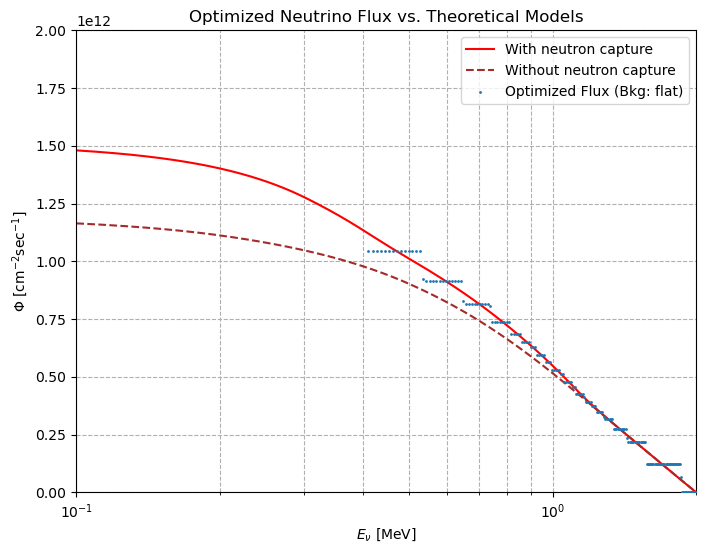

In [4]:
from neutrino_analysis_band import NeutrinoAnalysis

a = NeutrinoAnalysis(background_scenario='flat', intervals='180',
                     GeV=0.32e16, solver='osqp')
a.optimize(a.data_vector)   # ベストフィットを先に求める (self.result を埋める)
result_flat = a.optimize(a.data_vector)
print("\nOptimization Complete.")
print(f"Minimum chi-squared: {result_flat.fun / a.c}")
# 3. Plot the primary result: the optimized flux vs. theory.
a.plot_flux_comparison(save = True)

In [5]:
# 1 パラメータ (index=1) の 1σ/90%/2σ バンドを一度に求める
band = a.find_confidence_band(
    fixed_index=0,
    levels=(0.678, 0.90, 0.954),
    num_pseudo_data=20,    # ブラケット用 (粗い)
    n_pseudo_edge=200,     # 端の精緻化用 (大きいほど安定・遅い)
    step=1.5,              # ブラケットの拡大率
    rel_tol=0.03,          # 端の相対許容幅
    seed=42,
    n_jobs=1,
    verbose=True,
)
band

[band idx=0] v0=1.0446e+12 (phys), bracketing with step=1.5
  upper bracket: 2.6773e+13
  lower bracket: 6.9642e+11
  level 0.678: [9.0880e+11, 1.1750e+13] (phys)
  level 0.900: [8.4227e+11, 2.1046e+13] (phys)
  level 0.954: [8.2119e+11, 2.2709e+13] (phys)


{'index': 0,
 'best_fit_raw': 8830197.814725753,
 'best_fit_physical': 1044634160795.644,
 'levels': (0.678, 0.9, 0.954),
 'band_raw': {0.678: (np.float64(7681993.303959862),
   np.float64(99323038.49982691)),
  0.9: (np.float64(7119619.980682497), np.float64(177902143.96348733)),
  0.954: (np.float64(6941464.541175544), np.float64(191954497.90799153))},
 'band_physical': {0.678: (np.float64(908798737774.2684),
   np.float64(11750160205687.598)),
  0.9: (np.float64(842268587834.0258), np.float64(21046262016137.555)),
  0.954: (np.float64(821192360330.927), np.float64(22708690115487.72))},
 'n_evaluations': 28}

In [6]:
# 物理単位での上下端を表に
import pandas as pd
rows = []
for lv, (lo, hi) in band['band_physical'].items():
    rows.append({'level': lv, 'lower': lo, 'upper': hi})
band_df = pd.DataFrame(rows)
print('best fit (phys) =', band['best_fit_physical'])
print('evaluations     =', band['n_evaluations'])
band_df

best fit (phys) = 1044634160795.644
evaluations     = 28


,level,lower,upper
0,0.678,9.087987e+11,1.175016e+13
1,0.900,8.422686e+11,2.104626e+13
2,0.954,8.211924e+11,2.270869e+13


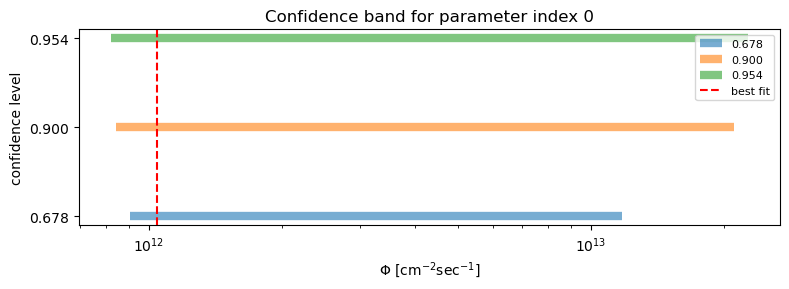

In [7]:
# バンドを可視化 (ベストフィットを中心に各レベルの区間を横棒で表示)
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 3))
colors = {0.678: 'C0', 0.90: 'C1', 0.954: 'C2'}
for i, lv in enumerate(band['levels']):
    lo, hi = band['band_physical'][lv]
    ax.hlines(i, lo, hi, color=colors.get(lv, 'k'), lw=6, alpha=0.6,
              label=f'{lv:.3f}')
ax.axvline(band['best_fit_physical'], color='red', ls='--', label='best fit')
ax.set_yticks(range(len(band['levels'])))
ax.set_yticklabels([f'{lv:.3f}' for lv in band['levels']])
ax.set_xscale('log')
ax.set_xlabel(r'$\Phi$ [cm$^{-2}$sec$^{-1}$]')
ax.set_ylabel('confidence level')
ax.set_title(f"Confidence band for parameter index {band['index']}")
ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

## 収束チェック (任意)

端の値は `n_pseudo_edge` に依存する（cutoff の Monte Carlo ノイズ）。
値を増やして端が安定するか確認するとよい。

In [ ]:
for npe in (100, 300):
    b = a.find_confidence_band(1, num_pseudo_data=20, n_pseudo_edge=npe,
                               seed=42, verbose=False)
    lo90, hi90 = b['band_physical'][0.90]
    print(f'n_pseudo_edge={npe:4d}  90% band = [{lo90:.4e}, {hi90:.4e}]  evals={b["n_evaluations"]}')

## 複数インデックスのバンドを保存して重ねる

1. インデックスごとに `find_and_save_band` を実行し、`bands/` 配下に 1 ファイルずつ JSON で保存する。
2. `plot_flux_with_bands` で保存済みファイルを読み込み、`optimize` の最適フラックス（散布図）の上に各インデックスのバンドを誤差棒として重ねる。

`save_band` / `load_band` は JSON 形式（人が読める）。バンドの中心は保存時の `self.result.x[index]` なので、同じ `optimize` 結果の散布図とちょうど重なる。

In [ ]:
# 複数インデックスでバンドを作り、インデックスごとに 1 ファイルへ保存
# 保存先は ./bands/band_bkg<scenario>_idx<NNN>.json
indices = [0, 5, 10, 20, 40]     # 走らせたいインデックス

for idx in indices:
    print(f'=== index {idx} ===')
    a.find_and_save_band(
        idx,
        outdir='bands',
        levels=(0.678, 0.90, 0.954),
        num_pseudo_data=20,
        n_pseudo_edge=200,
        step=1.5,
        rel_tol=0.03,
        seed=42,
        n_jobs=1,
        verbose=True,
    )

In [ ]:
# 保存したバンドを読み込んで optimize 結果の上に重ねる
# band_files はグロブパターンでも、明示的なリストでもよい
a.plot_flux_with_bands(
    f'bands/band_bkg{a.background_scenario}_idx*.json',
    levels=(0.678, 0.90, 0.954),   # 表示するレベル (省略すると保存済み全レベル)
    save=True,
    ylim=(0, 3e13),                # 高フラックス側の裾まで見えるように
)
import matplotlib.pyplot as plt
plt.show()